In [36]:
# Q7
import pandas as pd
from sklearn.naive_bayes import BernoulliNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
%matplotlib inline

In [37]:
df = pd.read_csv('/Users/kushbajpai/Downloads/asia_data.csv')
df

,V1,V2,V3,V4,V5,V6,V7,V8
0,2,2,1,1,1,2,1,2
1,2,1,1,1,1,1,2,1
2,1,1,2,1,1,1,2,1
3,2,1,2,1,1,1,2,1
4,2,1,2,1,1,1,1,2
...,...,...,...,...,...,...,...,...
9995,1,1,2,1,1,1,1,1
9996,2,1,2,1,1,1,2,2
9997,1,1,1,1,1,1,2,1
9998,2,1,1,1,1,1,2,1


In [38]:
col_map = {
    'V1': 'Asia',
    'V2': 'Tuberculosis',
    'V3': 'Smoking',
    'V4': 'LungCancer',
    'V5': 'Bronchitis',
    'V6': 'TBorLC',
    'V7': 'XRay',
    'V8': 'Dyspnea'
}
df = df.rename(columns=col_map)
df

,Asia,Tuberculosis,Smoking,LungCancer,Bronchitis,TBorLC,XRay,Dyspnea
0,2,2,1,1,1,2,1,2
1,2,1,1,1,1,1,2,1
2,1,1,2,1,1,1,2,1
3,2,1,2,1,1,1,2,1
4,2,1,2,1,1,1,1,2
...,...,...,...,...,...,...,...,...
9995,1,1,2,1,1,1,1,1
9996,2,1,2,1,1,1,2,2
9997,1,1,1,1,1,1,2,1
9998,2,1,1,1,1,1,2,1


In [39]:
X = df.drop(columns='LungCancer')
y = df['LungCancer']

In [40]:
X_train, X_test, y_train, y_test = train_test_split(
	X, y, test_size=0.2, random_state=11, stratify=y
)

In [41]:
model = BernoulliNB()
model.fit(X_train, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"binarize binarize: float or None, default=0.0Threshold for binarizing (mapping to booleans) of sample features.If None, input is presumed to already consist of binary vectors.",0.0
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [42]:
pred = model.predict(X_test)

In [43]:
accuracy_score(y_test, pred)

0.991

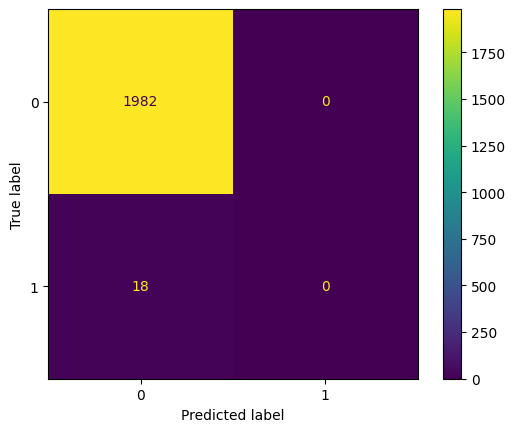

In [44]:
cm = confusion_matrix(y_test, pred)
ConfusionMatrixDisplay(cm).plot()

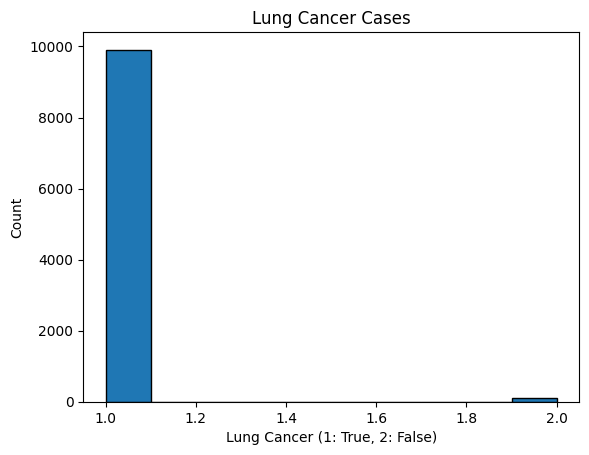

In [45]:
plt.hist(y, edgecolor='k')
plt.title("Lung Cancer Cases")
plt.xlabel("Lung Cancer (1: True, 2: False)")
plt.ylabel("Count")
plt.show()